In [1]:
# Celda 1 — Montar Drive
from google.colab import drive
drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, glob, os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
print("Setup completado.")

Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Ensamblar tabla comparativa desde CSVs individuales
csv_files = sorted(glob.glob(DRIVE_PATH + "resultado_*.csv"))
print(f"Encontrados {len(csv_files)} archivos de resultado:")
for f in csv_files:
    print(f"  {'✓' if os.path.exists(f) else '✗'} {os.path.basename(f)}")

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No se encontraron CSVs de resultado. "
        "Ejecuta primero los notebooks individuales: 03_modelos_LR, _KNN, _RF, _MLP, _SVM, etc."
    )

# Leer y concatenar todos los CSVs
dfs = []
for f in csv_files:
    df = pd.read_csv(f, index_col="Modelo")
    dfs.append(df)

tabla_final = pd.concat(dfs)
print(f"\n{len(tabla_final)} modelos cargados.")

Encontrados 15 archivos de resultado:
  ✓ resultado_CatBoost.csv
  ✓ resultado_CatBoost_base.csv
  ✓ resultado_HistGB_base.csv
  ✓ resultado_HistGradientBoosting.csv
  ✓ resultado_KNN_k25_100K.csv
  ✓ resultado_LightGBM.csv
  ✓ resultado_LightGBM_base.csv
  ✓ resultado_RF_base.csv
  ✓ resultado_Random_Forest.csv
  ✓ resultado_Red_Neuronal_MLP.csv
  ✓ resultado_Reg_Logística.csv
  ✓ resultado_SVM_linear.csv
  ✓ resultado_Stacking_5_trees_+_LR.csv
  ✓ resultado_XGBoost.csv
  ✓ resultado_XGBoost_base.csv

15 modelos cargados.


TABLA COMPARATIVA FINAL — TODOS LOS MODELOS
                        AUC CV (mean±2σ)  AUC Val  AUC Test  F1 Test  Acc Test  Precision Test  Recall Test
Modelo                                                                                                     
Red Neuronal (MLP)         0.820 ± 0.006    0.829     0.826    0.764     0.746           0.752        0.777
XGBoost                    0.823 ± 0.004    0.828     0.826    0.761     0.744           0.754        0.768
CatBoost                   0.823 ± 0.003    0.827     0.825    0.761     0.744           0.752        0.771
HistGradientBoosting       0.821 ± 0.003    0.826     0.825    0.760     0.744           0.754        0.767
Stacking (5 trees + LR)    0.823 ± 0.004    0.827     0.825    0.760     0.744           0.754        0.767
LightGBM                   0.822 ± 0.004    0.826     0.824    0.760     0.744           0.754        0.766
XGBoost (base)             0.821 ± 0.004    0.825     0.823    0.759     0.742           0.7

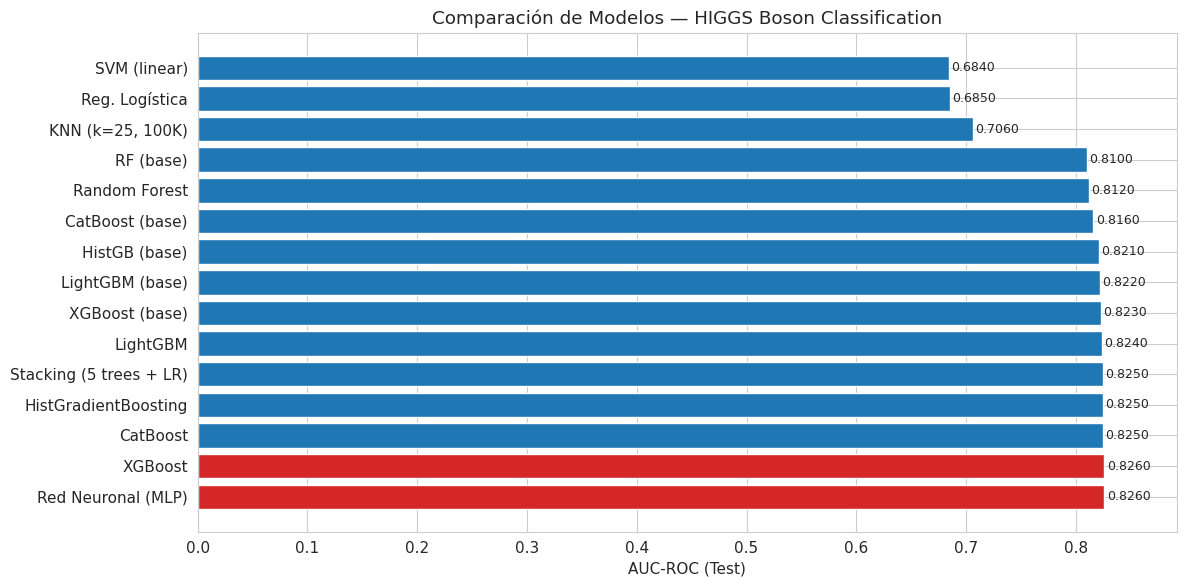

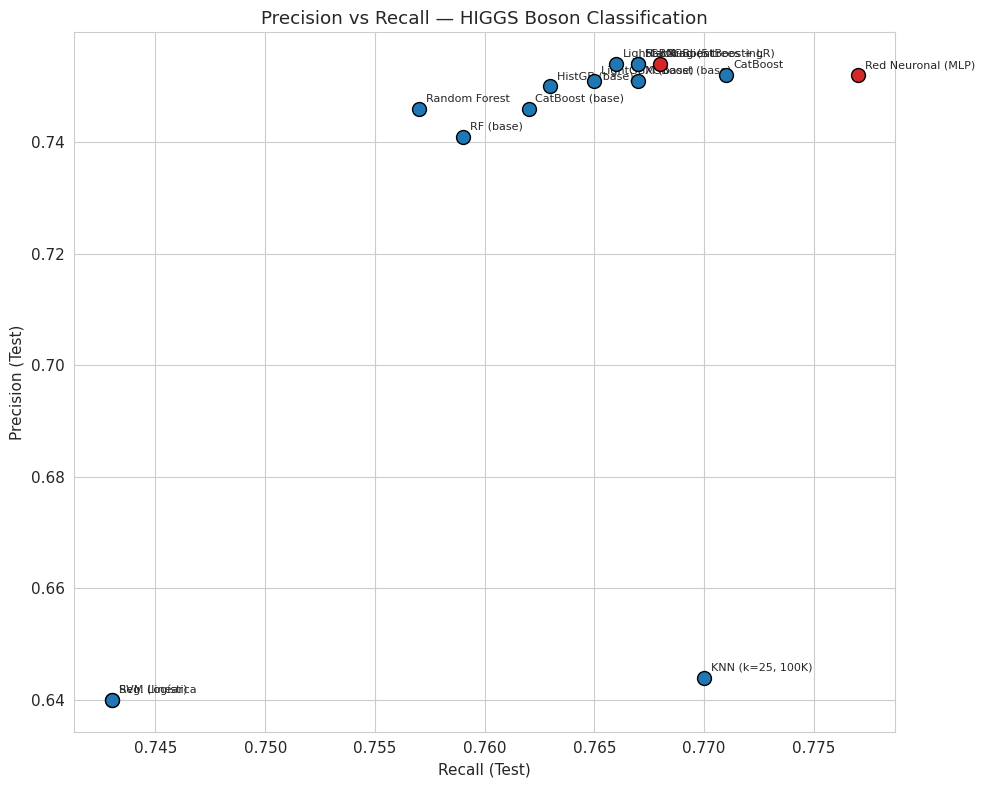


tabla_comparativa_modelos.csv guardado.
top2_modelos.npy guardado.

Verificación de pickles top-2:
  ✓ modelo_Red_Neuronal_MLP.pkl (0.3 MB)
  ✓ modelo_XGBoost.pkl (33.4 MB)

Ensamblaje completo.


In [3]:
# Celda 3 — Tabla comparativa, top-2, gráfica y guardar artefactos
print("TABLA COMPARATIVA FINAL — TODOS LOS MODELOS")
print("=" * 80)

# Ordenar por AUC Test (descendente)
# Extraer AUC_test numérico de la columna formateada
tabla_final["_AUC_test_num"] = tabla_final["AUC Test"].astype(float)
tabla_final = tabla_final.sort_values("_AUC_test_num", ascending=False)

# Mostrar tabla completa (sin columna auxiliar)
cols_show = [c for c in tabla_final.columns if not c.startswith("_")]
print(tabla_final[cols_show].to_string())

# Top 2 por AUC-ROC en test
aucs_test = tabla_final["_AUC_test_num"].to_dict()
top2 = list(aucs_test.keys())[:2]
print(f"\nTop 2 modelos por AUC-ROC en test: {top2}")

# Gráfica comparativa: AUC Test de todos los modelos
fig, ax = plt.subplots(figsize=(12, 6))
aucs = tabla_final["_AUC_test_num"]
labels = tabla_final.index
colors = ["#d62728" if l in top2 else "#1f77b4" for l in labels]
bars = ax.barh(labels, aucs, color=colors)
ax.set_xlabel("AUC-ROC (Test)")
ax.set_title("Comparación de Modelos — HIGGS Boson Classification")
# Anotar valores
for bar, val in zip(bars, aucs):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.4f}",
            va="center", fontsize=9)
ax.set_xlim(0, max(aucs) * 1.08)
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_comparacion_global.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica comparativa: Precision vs Recall Test
if "Precision Test" in tabla_final.columns and "Recall Test" in tabla_final.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    prec = tabla_final["Precision Test"].astype(float)
    rec = tabla_final["Recall Test"].astype(float)
    for i, label in enumerate(tabla_final.index):
        ax.scatter(rec.iloc[i], prec.iloc[i], s=100, c=colors[i], edgecolors="black", zorder=5)
        ax.annotate(label, (rec.iloc[i], prec.iloc[i]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Recall (Test)")
    ax.set_ylabel("Precision (Test)")
    ax.set_title("Precision vs Recall — HIGGS Boson Classification")
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(DRIVE_PATH + "fig_precision_recall.png", dpi=150, bbox_inches="tight")
    plt.show()

# Guardar tabla comparativa final
tabla_final[cols_show].to_csv(DRIVE_PATH + "tabla_comparativa_modelos.csv")
print("\ntabla_comparativa_modelos.csv guardado.")

# Guardar top 2 nombres
np.save(DRIVE_PATH + "top2_modelos.npy", np.array(top2))
print("top2_modelos.npy guardado.")

# Verificar pickles de top 2
print("\nVerificación de pickles top-2:")
for modelo in top2:
    safe = modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
    pkl_path = DRIVE_PATH + f"modelo_{safe}.pkl"
    if os.path.exists(pkl_path):
        size_mb = os.path.getsize(pkl_path) / (1024 * 1024)
        print(f"  ✓ {os.path.basename(pkl_path)} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ FALTA: {os.path.basename(pkl_path)} — ejecuta el notebook de {modelo}")

# Drop columna auxiliar antes de guardar
tabla_final = tabla_final[cols_show]

print("\nEnsamblaje completo.")